In [7]:

import pandas as pd
from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor, IsolationForest
import pickle
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import numpy as np
from scipy import stats
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
import shap
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import sklearn

In [8]:
print('The scikit-learn version is {}.'.format(sklearn.__version__))

The scikit-learn version is 1.5.1.


In [26]:
##read in the data parquet file

df = pd.read_parquet(r'C:\Users\crabt\Downloads\train_all_joinedDATE_fe_delta_years=4.parquet')
unique_key = df['unique_key']
df_model = df.drop(columns = ['unique_key'])
df_model['month'] = pd.to_datetime(df_model['month']).dt.month
df_model.isnull().sum().sort_values(ascending = False).head(20)
df_model

,month,day,crsdeptime,avg_delay_route_last_30d,avg_delay_airline_dest_last_14d,rank,air_safety__general_aviation_fatalities,us_airline_traffic__total__seasonally_adjusted,us_airline_traffic__international__seasonally_adjusted,us_airline_traffic__domestic__seasonally_adjusted,...,aircraft_service_attendants_and_transportation_workers_all_other,Date,DayShort,isUSA_Holiday,isUSA_Workingday,isLongweekend,MonthPart,DatePart,YearPart,FirstDayofMonth
index,,,,,,,,,,,,,,,,,,,,,
0,10,11,900,4.235000,3.562500,15.0,20.0,62000000.0,5460000.0,56550000.0,...,NaN,10/11/21,Mon,1,0,1,10,11,21,2021-10-01
1,10,11,1940,14.283333,9.436451,NaN,20.0,62000000.0,5460000.0,56550000.0,...,NaN,10/11/21,Mon,1,0,1,10,11,21,2021-10-01
2,10,11,945,9.993902,58.208367,NaN,20.0,62000000.0,5460000.0,56550000.0,...,NaN,10/11/21,Mon,1,0,1,10,11,21,2021-10-01
3,10,11,1420,19.506608,33.505193,11.0,20.0,62000000.0,5460000.0,56550000.0,...,NaN,10/11/21,Mon,1,0,1,10,11,21,2021-10-01
4,10,11,605,-6.142857,9.436451,NaN,20.0,62000000.0,5460000.0,56550000.0,...,NaN,10/11/21,Mon,1,0,1,10,11,21,2021-10-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1877378,5,18,523,-6.389140,-3.105938,21.0,14.0,3010000.0,140000.0,2870000.0,...,33430.0,05/18/20,Mon,0,1,0,5,18,20,2020-05-01
1877379,5,18,1205,-3.320675,-3.105938,11.0,14.0,3010000.0,140000.0,2870000.0,...,33430.0,05/18/20,Mon,0,1,0,5,18,20,2020-05-01
1877380,5,18,730,-6.997101,2.414634,14.0,14.0,3010000.0,140000.0,2870000.0,...,33430.0,05/18/20,Mon,0,1,0,5,18,20,2020-05-01


In [27]:
##DUMMIES 
df_model['hour'] = df_model['crsdeptime'].astype(str).str[:-2]
df_model = pd.get_dummies(df_model, columns= ['month'
                                            ,'day'
                                            , 'hour'
                                            , 'DayShort'])

df_model = df_model.drop( columns= ['crsdeptime'
                                    , 'Date'
                                    , 'MonthPart'
                                    , 'DatePart'
                                    , 'YearPart'
                                    , 'FirstDayofMonth'])

df_model.columns

Index(['avg_delay_route_last_30d', 'avg_delay_airline_dest_last_14d', 'rank',
       'air_safety__general_aviation_fatalities',
       'us_airline_traffic__total__seasonally_adjusted',
       'us_airline_traffic__international__seasonally_adjusted',
       'us_airline_traffic__domestic__seasonally_adjusted',
       'state_and_local_government_construction_spending__conservation_and_development',
       'state_and_local_government_construction_spending__lighting',
       'state_and_local_government_construction_spending__power',
       ...
       'hour_7', 'hour_8', 'hour_9', 'DayShort_Fri', 'DayShort_Mon',
       'DayShort_Sat', 'DayShort_Sun', 'DayShort_Thu', 'DayShort_Tue',
       'DayShort_Wed'],
      dtype='object', length=144)

In [28]:
df_model.columns

Index(['avg_delay_route_last_30d', 'avg_delay_airline_dest_last_14d', 'rank',
       'air_safety__general_aviation_fatalities',
       'us_airline_traffic__total__seasonally_adjusted',
       'us_airline_traffic__international__seasonally_adjusted',
       'us_airline_traffic__domestic__seasonally_adjusted',
       'state_and_local_government_construction_spending__conservation_and_development',
       'state_and_local_government_construction_spending__lighting',
       'state_and_local_government_construction_spending__power',
       ...
       'hour_7', 'hour_8', 'hour_9', 'DayShort_Fri', 'DayShort_Mon',
       'DayShort_Sat', 'DayShort_Sun', 'DayShort_Thu', 'DayShort_Tue',
       'DayShort_Wed'],
      dtype='object', length=144)

In [29]:
#apply function to the data
df_model.loc[df_model['arrdelay'] <= 15
            , 'arrival_category'] = 'On-Time'

df_model.loc[(df_model['arrdelay'] > 15) & (df_model['arrdelay'] <= 45)
            , 'arrival_category'] = 'Late'

df_model['arrival_category'].fillna('Very Late'
                                   , inplace = True)



np.unique(df_model['arrival_category'], return_counts = True)

C:\Users\crabt\AppData\Local\Temp\ipykernel_3884\3240646247.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_model['arrival_category'].fillna('Very Late'


(array(['Late', 'On-Time', 'Very Late'], dtype=object),
 array([ 189478, 1475479,  212426], dtype=int64))

#first we want to remove outliers from the dataset.  
# let's remove rows with a value that has a z-score outside of +/-3.1 
# we have a very large data set, so we expect to have a relatively large number of extreme values
threshold = 3.15
z_scores = np.abs(stats.zscore(df_model))
outlier_indices = np.where(z_scores > threshold)[0]
#df_model_or = df_model.drop(outlier_indices)
#unique_key_or = unique_key.drop(outlier_indices)
len(outlier_indices)
#we will remove about 38k rows with outliers.  1.4% of the rows

In [30]:
#create my predictor and response variables
X = df_model.drop(columns = ['arrdelay'
             , "arrival_category"])
y = df_model["arrival_category"]
X_train, X_test, y_train, y_test = train_test_split(X
                                                    , y
                                                    , test_size=0.2
                                                    , random_state=42)

In [31]:
params = dict(learning_rate = [0.05,0.1,0.2,0.4,0.6]
             , min_samples_leaf = [20,50,100,200]
             , max_leaf_nodes = [31,100,300,600])
#build model
gb_model = HistGradientBoostingClassifier(learning_rate = 0.4
                                         , min_samples_leaf = 100
                                         , max_leaf_nodes = 300
                                         ).fit(X
                                            , y)

#clf = RandomizedSearchCV(gb_model, params, random_state=0, n_iter = 5)
#search = clf
#search.best_params_
gb_model


HistGradientBoostingClassifier(learning_rate=0.4, max_leaf_nodes=300,
                               min_samples_leaf=100)

In [85]:
gb_model.score(X_test
            , y_test)

0.8122548118792895

In [87]:
pred_train = gb_model.predict(X_train)
test_pred = gb_model.predict(X_test)

print(classification_report(y_train, pred_train))

print(classification_report(y_test, test_pred))

              precision    recall  f1-score   support

        Late       0.53      0.04      0.08    151857
     On-Time       0.83      0.98      0.90   1180050
   Very Late       0.66      0.37      0.48    169999

    accuracy                           0.82   1501906
   macro avg       0.67      0.47      0.49   1501906
weighted avg       0.78      0.82      0.77   1501906

              precision    recall  f1-score   support

        Late       0.31      0.02      0.04     37621
     On-Time       0.83      0.98      0.90    295429
   Very Late       0.61      0.34      0.44     42427

    accuracy                           0.81    375477
   macro avg       0.59      0.45      0.46    375477
weighted avg       0.75      0.81      0.76    375477



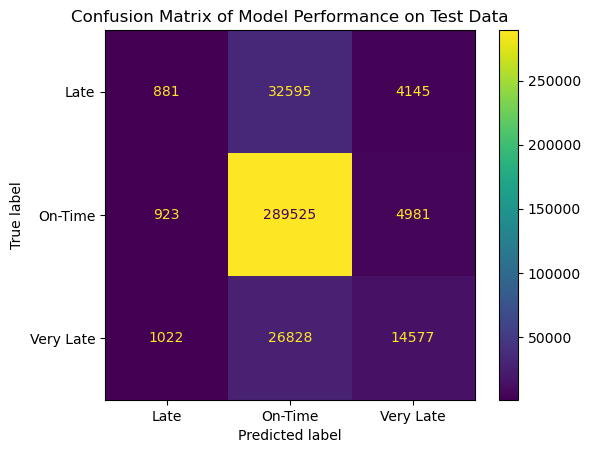

In [108]:
cm = confusion_matrix(y_test, test_pred)
disp = ConfusionMatrixDisplay(cm
                              ,display_labels =  gb_model.classes_)
disp.plot()
plt.title('Confusion Matrix of Model Performance on Test Data')
plt.show()

In [136]:
##read in the data parquet file for test set

df2 = pd.read_parquet(r'C:\Users\crabt\Downloads\test_all_joined_fe_delta_years=1 (2).parquet')
unique_key = df2['unique_key']
df2_model = df2.drop(columns = ['unique_key'])
df2_model['month'] = pd.to_datetime(df2_model['dt']).dt.month

df2_model.isnull().sum().sort_values(ascending = False).head(20)
df2_model

,month,day,crsdeptime,avg_delay_route_last_30d,avg_delay_airline_dest_last_14d,__index_level_0__,rank,air_safety__general_aviation_fatalities,us_airline_traffic__total__seasonally_adjusted,us_airline_traffic__international__seasonally_adjusted,...,operating_airline_YX,operating_airline_ZW,arrdelay,dt_obj,dt,Date,DayShort,isUSA_Holiday,isUSA_Workingday,isLongweekend
0,1,20,800,-10.617866,-0.640712,0,12.0,42.0,68330000.0,7130000.0,...,0,0,-25.0,2022-01-20,2022-01-20,2022-01-20,Thu,0,1,0
1,1,2,1955,-2.893204,-0.423077,1,27.0,42.0,68330000.0,7130000.0,...,1,0,60.0,2022-01-02,2022-01-02,2022-01-02,Sun,0,0,1
2,1,13,1259,-0.985507,6.407738,2,13.0,42.0,68330000.0,7130000.0,...,0,0,-6.0,2022-01-13,2022-01-13,2022-01-13,Thu,0,1,0
3,1,11,1720,-9.772727,-2.223708,3,NaN,42.0,68330000.0,7130000.0,...,0,0,-14.0,2022-01-11,2022-01-11,2022-01-11,Tue,0,1,0
4,1,11,1300,-1.142045,-2.288889,4,19.0,42.0,68330000.0,7130000.0,...,0,0,-35.0,2022-01-11,2022-01-11,2022-01-11,Tue,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1373661,6,12,1229,NaN,NaN,349660,13.0,29.0,71170000.0,8400000.0,...,0,0,14.0,2022-06-12,2022-06-12,2022-06-12,Sun,0,0,0
1373662,4,4,930,NaN,NaN,349661,19.0,23.0,69790000.0,7680000.0,...,0,0,-8.0,2022-04-04,2022-04-04,2022-04-04,Mon,0,1,0
1373663,3,10,1739,NaN,NaN,349662,NaN,26.0,66100000.0,7010000.0,...,0,0,-5.0,2022-03-10,2022-03-10,2022-03-10,Thu,0,1,0
1373664,2,9,1830,NaN,NaN,349663,19.0,8.0,60600000.0,6410000.0,...,0,0,-27.0,2022-02-09,2022-02-09,2022-02-09,Wed,0,1,0


In [137]:
##DUMMIES 
df2_model['keep'] = 1
df2_model['hour'] = df2_model['crsdeptime'].astype(str).str[:-2]
df2_model = pd.get_dummies(df2_model, columns= ['month'
                                            ,'day'
                                            , 'hour'
                                            , 'DayShort'])

df2_model = df2_model.drop( columns= ['crsdeptime'
                                    , 'Date'
                                    , 'dt_obj'
                                    , 'dt'
                                    , '__index_level_0__'])

df2_model.columns

Index(['avg_delay_route_last_30d', 'avg_delay_airline_dest_last_14d', 'rank',
       'air_safety__general_aviation_fatalities',
       'us_airline_traffic__total__seasonally_adjusted',
       'us_airline_traffic__international__seasonally_adjusted',
       'us_airline_traffic__domestic__seasonally_adjusted',
       'state_and_local_government_construction_spending__conservation_and_development',
       'state_and_local_government_construction_spending__lighting',
       'state_and_local_government_construction_spending__power',
       ...
       'hour_7', 'hour_8', 'hour_9', 'DayShort_Fri', 'DayShort_Mon',
       'DayShort_Sat', 'DayShort_Sun', 'DayShort_Thu', 'DayShort_Tue',
       'DayShort_Wed'],
      dtype='object', length=241)

In [138]:
#code from when I read the data in using Polars.  I don't think I need it anymore
'''df_model_or = df.with_columns(pl.when(pl.col("arrdelay") <= 15)
    .then(pl.lit('On-Time'))
    .when((pl.col("arrdelay") > 15)&(pl.col("arrdelay") <= 30))
    .then(pl.lit('Late'))
    .otherwise(pl.lit('Very Late'))
    .alias("arrival_category"))'''

#create a function to categorize each arrival
def arrival_category(row):
    if row['arrdelay'] <= 15:
        return 'On-Time'
    elif (row['arrdelay'] > 15) and (row['arrdelay'] <= 45):
        return 'Late'
    else:
        return 'Very Late'

#apply function to the data
df2_model.loc[df2_model['arrdelay'] <= 15
            , 'arrival_category'] = 'On-Time'

df2_model.loc[(df_model['arrdelay'] > 15) & (df2_model['arrdelay'] <= 45)
            , 'arrival_category'] = 'Late'

df2_model['arrival_category'].fillna('Very Late'
                                   , inplace = True)



np.unique(df2_model['arrival_category'], return_counts = True)

(array(['Late', 'On-Time', 'Very Late'], dtype=object),
 array([267433, 798240, 307993], dtype=int64))

In [139]:
df2_model = pd.concat([df_model, df2_model])
df2_model = df2_model[df2_model['keep']==1]
df2_model.drop(columns = ['keep']
              , inplace = True)

In [143]:
set_difference = set(df2_model.columns).difference(set(df_model.columns))
df2_model.drop(columns = list(set_difference)
              , inplace = True)

In [144]:
X_t = df2_model.drop(columns = ['arrdelay'
             , "arrival_category"])
y_t = df2_model["arrival_category"]

In [160]:
test_pred = gb_model.predict(X_t.iloc[[0]])


print(classification_report(y_t, test_pred))

ValueError: Found input variables with inconsistent numbers of samples: [1373666, 1]

In [163]:
X['unique_key'] = unique_key


,avg_delay_route_last_30d,avg_delay_airline_dest_last_14d,rank,air_safety__general_aviation_fatalities,us_airline_traffic__total__seasonally_adjusted,us_airline_traffic__international__seasonally_adjusted,us_airline_traffic__domestic__seasonally_adjusted,state_and_local_government_construction_spending__conservation_and_development,state_and_local_government_construction_spending__lighting,state_and_local_government_construction_spending__power,...,hour_8,hour_9,DayShort_Fri,DayShort_Mon,DayShort_Sat,DayShort_Sun,DayShort_Thu,DayShort_Tue,DayShort_Wed,unique_key
index,,,,,,,,,,,,,,,,,,,,,
0,4.235000,3.562500,15.0,20.0,62000000.0,5460000.0,56550000.0,291000000.0,244000000.0,739000000.0,...,0,1,0,1,0,0,0,0,0,2022-01-20-800-AA-DCA-LGA
1,14.283333,9.436451,NaN,20.0,62000000.0,5460000.0,56550000.0,291000000.0,244000000.0,739000000.0,...,0,0,0,1,0,0,0,0,0,2022-01-02-1955-YX-EWR-DTW
2,9.993902,58.208367,NaN,20.0,62000000.0,5460000.0,56550000.0,291000000.0,244000000.0,739000000.0,...,0,1,0,1,0,0,0,0,0,2022-01-13-1259-AA-LGA-MIA
3,19.506608,33.505193,11.0,20.0,62000000.0,5460000.0,56550000.0,291000000.0,244000000.0,739000000.0,...,0,0,0,1,0,0,0,0,0,2022-01-11-1720-9E-GSO-LGA
4,-6.142857,9.436451,NaN,20.0,62000000.0,5460000.0,56550000.0,291000000.0,244000000.0,739000000.0,...,0,0,0,1,0,0,0,0,0,2022-01-11-1300-DL-JFK-TPA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1877378,-6.389140,-3.105938,21.0,14.0,3010000.0,140000.0,2870000.0,244000000.0,233000000.0,586000000.0,...,0,0,0,1,0,0,0,0,0,NaN
1877379,-3.320675,-3.105938,11.0,14.0,3010000.0,140000.0,2870000.0,244000000.0,233000000.0,586000000.0,...,0,0,0,1,0,0,0,0,0,NaN
1877380,-6.997101,2.414634,14.0,14.0,3010000.0,140000.0,2870000.0,244000000.0,233000000.0,586000000.0,...,0,0,0,1,0,0,0,0,0,NaN


In [ ]:
filename = 'prediction_probabilities.pkl'
with open(filename, 'wb') as file:  # Open file in write-binary mode
    pickle.dump(gb_model.predict_proba(X), file)
print(f"Object pickled and saved to {filename}")

In [32]:
filename = 'gradient_boost_model.pkl'
with open(filename, 'wb') as file:  # Open file in write-binary mode
    pickle.dump(gb_model, file)
print(f"Object pickled and saved to {filename}")

Object pickled and saved to gradient_boost_model.pkl


In [ ]:
filename = 'prediction_classes.pkl'
with open(filename, 'wb') as file:  # Open file in write-binary mode
    pickle.dump(gb_model.predict(X), file)
print(f"Object pickled and saved to {filename}")

In [33]:
X.iloc[0:3].to_csv('data_for_columns.csv',index = False)